IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

LOAD DATASET

In [2]:
df = pd.read_csv(
    "../data/raw/reliance.csv",
    index_col=0,
    parse_dates=True
)

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_21156\2773123656.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


,Close,High,Low,Open,Volume
Price,,,,,
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,NaN,NaN,NaN,NaN,NaN
2020-01-01,675.3241577148438,683.1528519736394,673.4900624593615,679.0819357370663,14004468
2020-01-02,686.8212280273438,689.3487905881979,676.397899264457,676.397899264457,17710316
2020-01-03,687.6488037109375,689.6618949086101,681.3187290426969,685.7922517653002,20984698


BASIC DATA INSPECTION

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1240 entries, Ticker to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Close   1239 non-null   object
 1   High    1239 non-null   object
 2   Low     1239 non-null   object
 3   Open    1239 non-null   object
 4   Volume  1239 non-null   object
dtypes: object(5)
memory usage: 58.1+ KB


CHECK MISSING VALUES

In [4]:
df.isnull().sum()

Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

In [8]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

CLOSING PRICE TREND

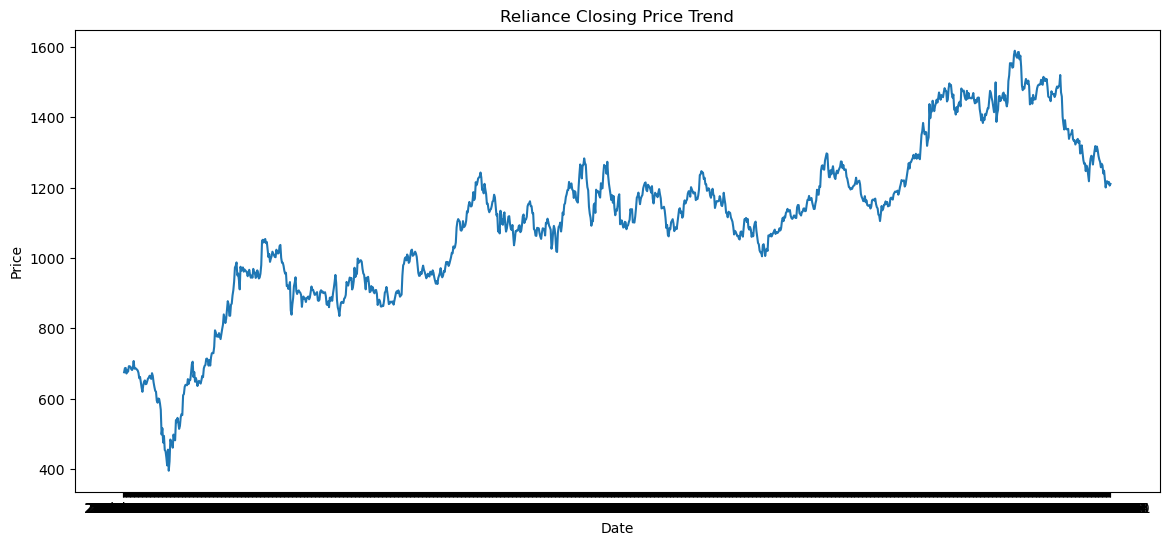

In [9]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'])

plt.title("Reliance Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

DESCRIPTIVE STATISTICS

In [7]:
df.describe()

,Close,High,Low,Open,Volume
count,1239,1239,1239,1239,1239
unique,1223,1239,1239,1239,1239
top,1153.178955078125,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
freq,2,1,1,1,1


SIMPLE MOVING AVERAGE (SMA)

In [13]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()

df['SMA_50'] = df['Close'].rolling(window=50).mean()

VISUALIZE

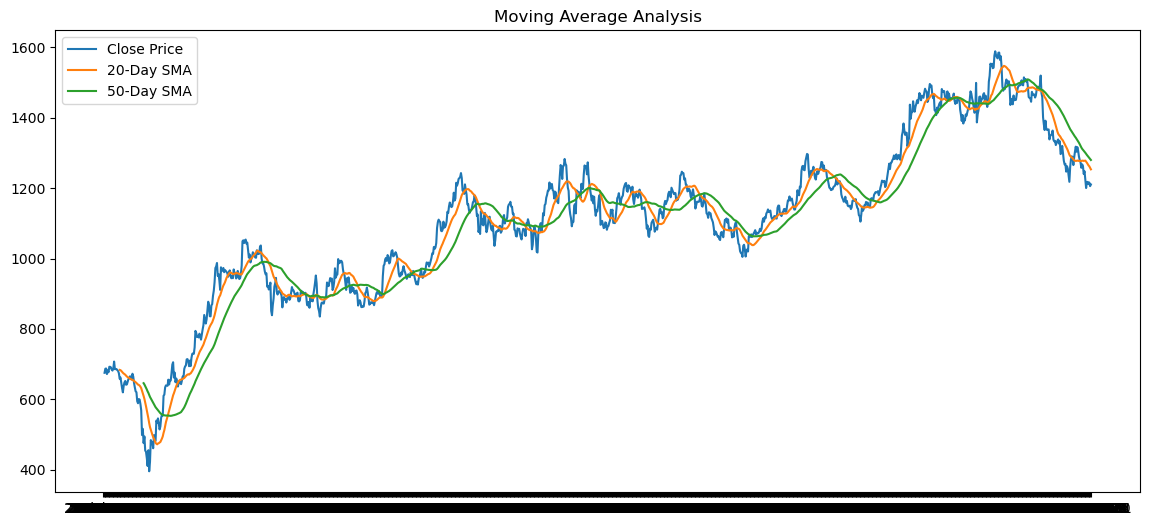

In [14]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'], label='Close Price')

plt.plot(df['SMA_20'], label='20-Day SMA')

plt.plot(df['SMA_50'], label='50-Day SMA')

plt.legend()

plt.title("Moving Average Analysis")

plt.show()

Calculate Daily Returns

In [15]:
df['Daily_Return'] = df['Close'].pct_change()

df.head()

,Close,High,Low,Open,Volume,SMA_20,SMA_50,Daily_Return
Price,,,,,,,,
Ticker,NaN,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,NaN,NaN,NaN
Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01,675.324158,683.1528519736394,673.4900624593615,679.0819357370663,14004468,NaN,NaN,NaN
2020-01-02,686.821228,689.3487905881979,676.397899264457,676.397899264457,17710316,NaN,NaN,0.017025
2020-01-03,687.648804,689.6618949086101,681.3187290426969,685.7922517653002,20984698,NaN,NaN,0.001205


VISUALIZE RETURNS

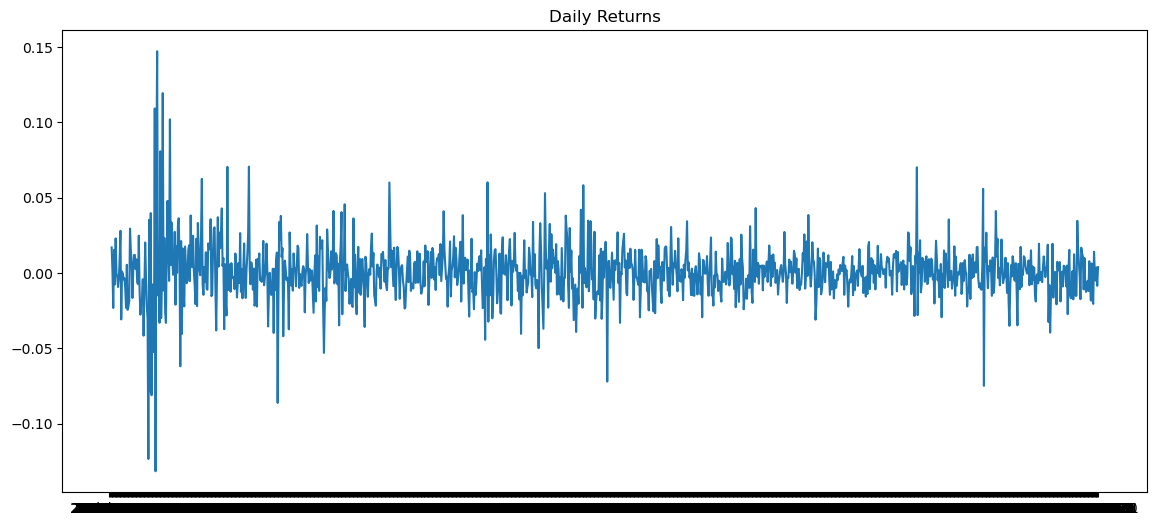

In [16]:
plt.figure(figsize=(14,6))

plt.plot(df['Daily_Return'])

plt.title("Daily Returns")

plt.show()

ROLLING VOLATILITY

In [17]:
df['Volatility'] = df['Daily_Return'].rolling(20).std()

PLOT VOLATILITY

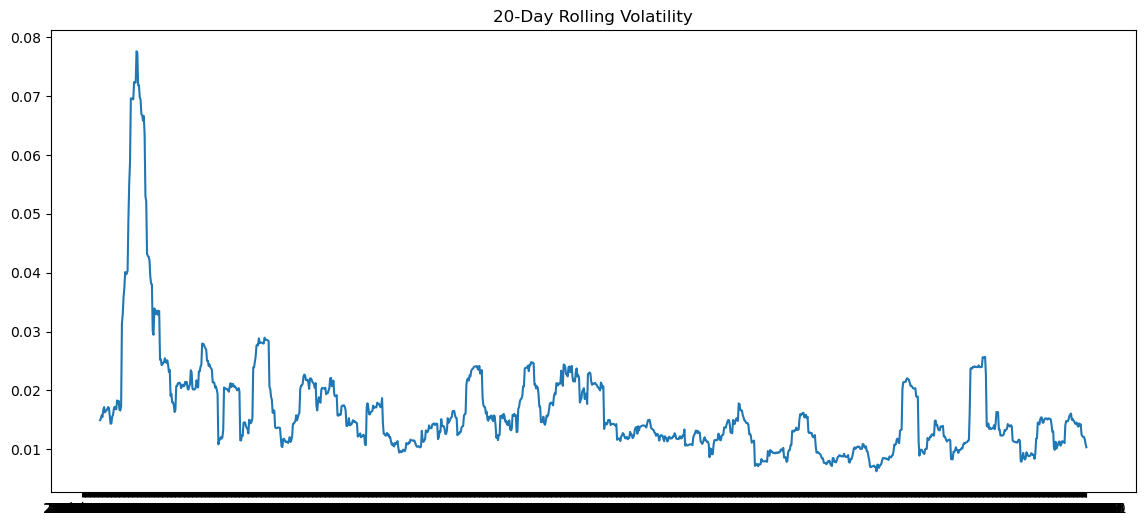

In [18]:
plt.figure(figsize=(14,6))

plt.plot(df['Volatility'])

plt.title("20-Day Rolling Volatility")

plt.show()

DISTRIBUTION OF RETURNS

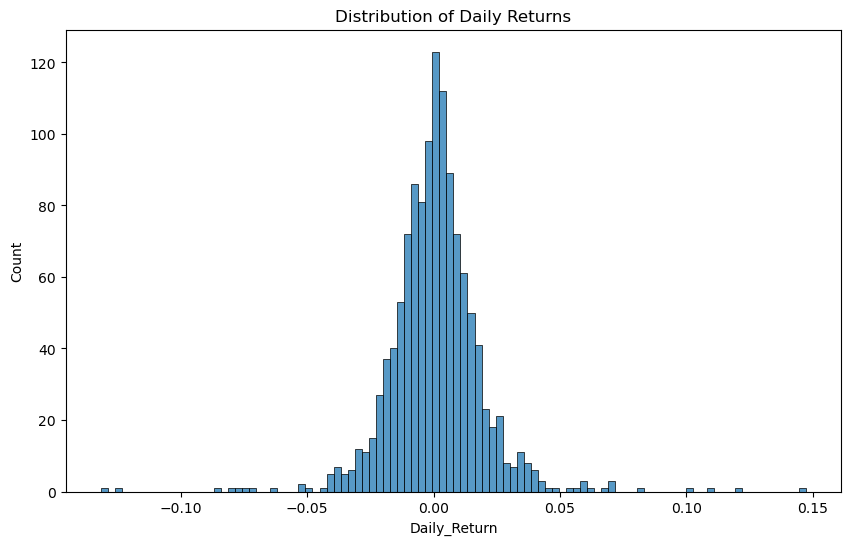

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(df['Daily_Return'].dropna(), bins=100)

plt.title("Distribution of Daily Returns")

plt.show()

DOWNLOAD MULTIPLE STOCKS

In [20]:
stocks = ["RELIANCE.NS", "TCS.NS", "INFY.NS"]

data = yf.download(
    stocks,
    start="2020-01-01"
)['Close']

[*********************100%***********************]  3 of 3 completed


CORRELATION MATRIX

In [21]:
correlation = data.corr()

correlation

Ticker,INFY.NS,RELIANCE.NS,TCS.NS
Ticker,,,
INFY.NS,1.000000,0.767526,0.920952
RELIANCE.NS,0.767526,1.000000,0.750473
TCS.NS,0.920952,0.750473,1.000000


HEATMAP

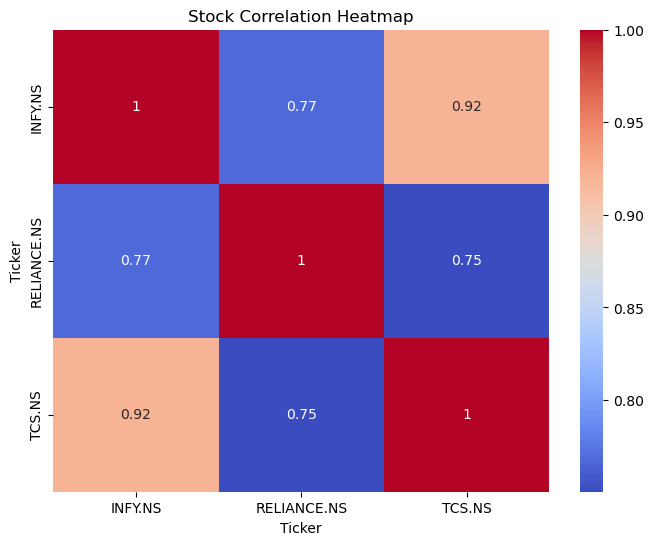

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Stock Correlation Heatmap")

plt.show()

CUMULATIVE RETURNS

In [23]:
cumulative_return = (1 + df['Daily_Return']).cumprod()

PLOT

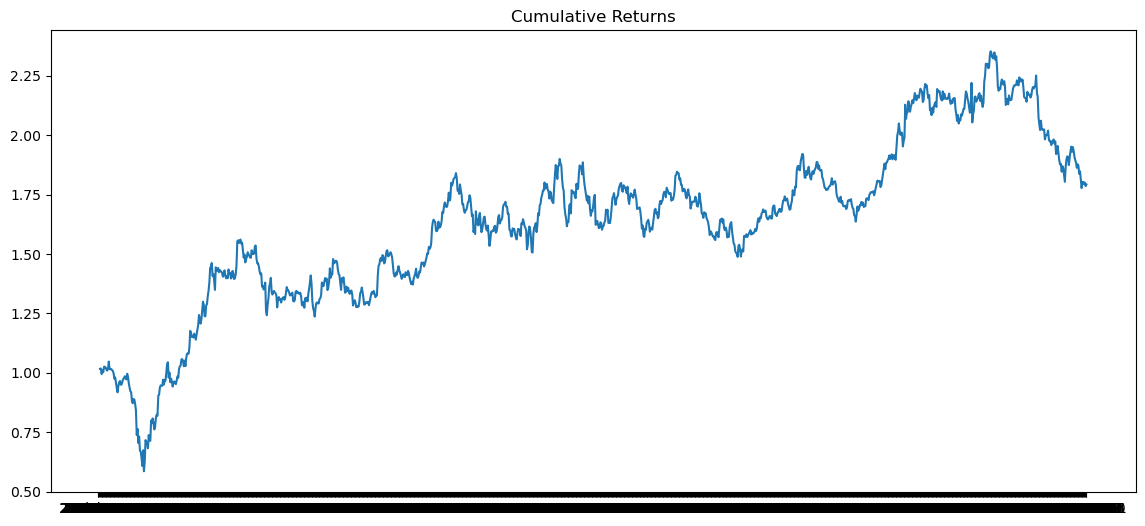

In [24]:
plt.figure(figsize=(14,6))

plt.plot(cumulative_return)

plt.title("Cumulative Returns")

plt.show()